Paso 1: Configuración del Stack Tecnológico
- Descripción: "Cargamos las librerías fundamentales para la manipulación de datos, análisis temporal y visualización estadística, preparando el entorno para el procesamiento del historial de compras."

In [1]:
# Importación de herramientas para análisis de datos y fechas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Configuración de visualización integrada
%matplotlib inline

Paso 2: Ingesta del Registro de Compras
- Descripción: "Realizamos la importación del archivo fuente que contiene el detalle de las compras finales. Utilizamos un DataFrame para estructurar la información y facilitar las etapas posteriores de limpieza."

In [2]:
# Lectura del archivo CSV original
df_compras = pd.read_csv("../data/PurchasesFINAL12312016.csv", delimiter=',')

Paso 3: Diagnóstico de Magnitud y Estructura
- Descripción: "Evaluamos el volumen de datos mediante la inspección de sus dimensiones. Este paso permite cuantificar el total de transacciones de compra registradas en el periodo."

In [3]:
# Verificación de la forma del conjunto de datos (filas, columnas)
print(f"Dimensiones del dataset de compras: {df_compras.shape}")

Dimensiones del dataset de compras: (2372474, 16)


Paso 4: Muestreo de Datos y Auditoría de Metadatos
- Descripción: "Realizamos una exploración visual de los primeros registros y verificamos la naturaleza técnica de cada columna para asegurar que los tipos de datos (numéricos, objetos, fechas) sean coherentes."

In [4]:
# Inspección de los 5 registros superiores
display(df_compras.head())

# Validación de tipos de datos asignados
print("Tipificación de columnas:")
print(df_compras.info())

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1


Tipificación de columnas:
<class 'pandas.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   InventoryId     str    
 1   Store           int64  
 2   Brand           int64  
 3   Description     str    
 4   Size            str    
 5   VendorNumber    int64  
 6   VendorName      str    
 7   PONumber        int64  
 8   PODate          str    
 9   ReceivingDate   str    
 10  InvoiceDate     str    
 11  PayDate         str    
 12  PurchasePrice   float64
 13  Quantity        int64  
 14  Dollars         float64
 15  Classification  int64  
dtypes: float64(2), int64(6), str(8)
memory usage: 289.6 MB
None


Paso 5: Detección de Vacíos de Información (Nulos)
- Descripción: "Ejecutamos una auditoría de valores faltantes para identificar columnas con datos incompletos. En caso de hallar registros nulos, procedemos a aislarlos para su análisis detallado."

In [5]:
# Conteo de celdas vacías por variable
conteo_vacios = df_compras.isna().sum()
print("Resumen de valores nulos detectados:")
print(conteo_vacios)

# Localización específica de filas con inconsistencias de nulos
mascara_nulos = df_compras.isnull().any(axis=1)
registros_con_nulos = df_compras[mascara_nulos]

if not registros_con_nulos.empty:
    print("\nRegistros incompletos localizados:")
    display(registros_con_nulos)
else:
    print("\nIntegridad confirmada: No se detectaron valores nulos.")

Resumen de valores nulos detectados:
InventoryId       0
Store             0
Brand             0
Description       0
Size              3
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

Registros incompletos localizados:


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
1109668,34_PITMERDEN_3121,34,3121,Pinnacle Rainbow Sherbet,NaN,12546,JIM BEAM BRANDS COMPANY,10938,2016-06-27,2016-07-04,2016-07-13,2016-08-16,6.93,7,48.51,1
1112426,34_PITMERDEN_5678,34,5678,Skinnygirl Pina Colada,NaN,12546,JIM BEAM BRANDS COMPANY,10938,2016-06-27,2016-07-09,2016-07-13,2016-08-16,6.93,6,41.58,1
1116302,39_EASTHALLOW_15365,39,15365,Alabaster 07 Tinta de Toro,NaN,9552,M S WALKER INC,10972,2016-06-29,2016-07-07,2016-07-13,2016-08-21,91.83,1,91.83,2


Paso 6: Control de Redundancia (Duplicados)
- Descripción: "Verificamos si existen registros idénticos en el historial de compras. Es fundamental identificar filas duplicadas para evitar sobreestimar los costos de adquisición y el volumen de inventario entrante."

In [6]:
# Cuantificación de filas repetidas en el dataset
total_duplicados = df_compras.duplicated().sum()

print(f"Cantidad de registros redundantes en Compras: {total_duplicados}")

# Despliegue de duplicados si existen para su revisión
if total_duplicados > 0:
    print("Detalle de las filas duplicadas encontradas:")
    display(df_compras[df_compras.duplicated()])

Cantidad de registros redundantes en Compras: 0


Paso 7: Conversión de Formatos Temporales
- Descripción: "Transformamos las columnas de fechas del formato genérico a objetos cronológicos (datetime). Este ajuste es indispensable para realizar análisis de tiempos de entrega, periodos de facturación y ciclos de pago."

In [7]:
# Definición de las variables con naturaleza de fecha
campos_temporales = ['PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate']

# Normalización masiva mediante un ciclo de conversión segura
for fecha in campos_temporales:
    df_compras[fecha] = pd.to_datetime(df_compras[fecha], errors='coerce')

# Verificación de la nueva estructura de tipos de datos
print("Tipos de datos actualizados:")
print(df_compras.dtypes)

Tipos de datos actualizados:
InventoryId                  str
Store                      int64
Brand                      int64
Description                  str
Size                         str
VendorNumber               int64
VendorName                   str
PONumber                   int64
PODate            datetime64[us]
ReceivingDate     datetime64[us]
InvoiceDate       datetime64[us]
PayDate           datetime64[us]
PurchasePrice            float64
Quantity                   int64
Dollars                  float64
Classification             int64
dtype: object


Paso 8: Gestión de Omisiones en Dimensiones (Size)
- Descripción: "Auditamos específicamente los valores nulos en la columna de tamaño. Tras identificar que la cantidad de registros afectados es insignificante frente al volumen total del dataset, procedemos a su remoción para mantener la calidad de la información."

In [8]:
# Aislamiento de registros con tamaño no especificado para auditoría
registros_size_nulos = df_compras.loc[df_compras['Size'].isna()]
print(f"Registros afectados identificados: {len(registros_size_nulos)}")

# Eliminación de filas con valores faltantes en la variable 'Size'
df_compras = df_compras.dropna(subset=['Size'])

# Confirmación de la limpieza y verificación de dimensiones actuales
print("\nConteo de nulos tras la depuración:")
print(df_compras.isna().sum())
print(f"\nNueva estructura del dataset (Filas, Columnas): {df_compras.shape}")

Registros afectados identificados: 3

Conteo de nulos tras la depuración:
InventoryId       0
Store             0
Brand             0
Description       0
Size              0
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

Nueva estructura del dataset (Filas, Columnas): (2372471, 16)


Paso 9: Escaneo de Integridad Financiera (Valores Negativos)
- Descripción: "Realizamos una inspección automática sobre todas las métricas numéricas para localizar valores negativos. Este control de calidad asegura que no existan errores de registro en costos, cantidades o identificadores antes de proceder con el análisis."

In [9]:
# Identificación de valores inferiores a cero en columnas cuantitativas
df_valores_numericos = df_compras.select_dtypes(include=[np.number])
presencia_negativos = (df_valores_numericos < 0).any()

# Extracción de nombres de variables con anomalías
nombres_cols_negativas = presencia_negativos[presencia_negativos].index.tolist()

# Reporte detallado de hallazgos
if nombres_cols_negativas:
    print(f"Alerta: Se detectaron valores negativos en: {nombres_cols_negativas}")
    for columna in nombres_cols_negativas:
        print(f"\nDetalle de registros anómalos en '{columna}':")
        display(df_compras[df_compras[columna] < 0])
else:
    print("Validación exitosa: El dataframe no contiene valores negativos en sus variables numéricas.")

Validación exitosa: El dataframe no contiene valores negativos en sus variables numéricas.


Paso 10: Auditoría Estadística Univariada
- Descripción: "Realizamos un recorrido descriptivo por todas las variables del dataset. Este barrido inicial nos permite identificar la dispersión de los datos, los valores centrales y detectar posibles anomalías en el historial de compras."

In [10]:
# Inspección automatizada de métricas para cada columna del DataFrame
for variable in df_compras.columns:
    print(f"Análisis de la Variable: {variable}")
    print(df_compras[variable].describe())
    print("-" * 35)

Análisis de la Variable: InventoryId
count               2372471
unique               245906
top       73_DONCASTER_8068
freq                    180
Name: InventoryId, dtype: object
-----------------------------------
Análisis de la Variable: Store
count    2.372471e+06
mean     4.465134e+01
std      2.351246e+01
min      1.000000e+00
25%      2.500000e+01
50%      4.800000e+01
75%      6.700000e+01
max      8.100000e+01
Name: Store, dtype: float64
-----------------------------------
Análisis de la Variable: Brand
count    2.372471e+06
mean     1.241865e+04
std      1.255728e+04
min      5.800000e+01
25%      3.639000e+03
50%      6.523000e+03
75%      1.887700e+04
max      9.063100e+04
Name: Brand, dtype: float64
-----------------------------------
Análisis de la Variable: Description
count                   2372471
unique                     9651
top       Tito's Handmade Vodka
freq                      16442
Name: Description, dtype: object
-----------------------------------
Anális

Paso 11: Ranking de Operaciones por Punto de Venta
- Descripción: "Cuantificamos el volumen de actividad logística por sucursal. Identificamos las tiendas con mayor flujo de pedidos recibidos para entender la distribución del abastecimiento en la red comercial."

In [11]:
# Contabilización de frecuencia de pedidos por ID de tienda
flujo_por_tienda = df_compras['Store'].value_counts().reset_index()
flujo_por_tienda.columns = ['ID_Tienda', 'Total_Pedidos']

# Extracción de las 11 sucursales con mayor actividad (Top 10 ampliado)
top_n_tiendas = flujo_por_tienda.iloc[:11]

print("Ranking de Sucursales con Mayor Volumen de Recepción:")
display(top_n_tiendas)

Ranking de Sucursales con Mayor Volumen de Recepción:


,ID_Tienda,Total_Pedidos
0,76,121123
1,73,96794
2,38,93412
3,34,92111
4,66,82699
5,67,69419
6,50,65512
7,69,63683
8,60,58169
9,41,53344


Paso 12: Integridad Logística (Fechas de Recepción por Orden)
- Descripción: "Analizamos si las órdenes de compra (PO) se completan en una sola entrega o si presentan entregas parciales en distintas fechas. Este indicador es clave para medir la eficiencia de los proveedores."

In [12]:
# Agrupación por Orden de Compra para verificar fechas de recepción únicas
entregas_por_orden = df_compras.groupby('PONumber')['ReceivingDate'].nunique().to_frame('Fechas_Distintas').reset_index()

# Filtrado de órdenes que requirieron múltiples recepciones
ordenes_fragmentadas = entregas_por_orden.query("Fechas_Distintas > 1")

print("Órdenes de Compra con Entregas Parciales Detectadas:")
display(ordenes_fragmentadas)

Órdenes de Compra con Entregas Parciales Detectadas:


,PONumber,Fechas_Distintas
0,8106,3
1,8107,2
2,8108,3
3,8109,3
4,8110,3
...,...,...
5538,13657,6
5539,13658,6
5540,13659,5
5541,13660,4


Paso 13: Identificación de Artículos de Alta Gama (Costo)
- Descripción: "Filtramos el catálogo de compras para localizar los 10 productos con el precio de adquisición más elevado. Esta información permite identificar los SKU que representan el mayor compromiso financiero para el inventario."

In [13]:
# Selección de los 10 registros con el costo de compra más alto
ranking_costo = df_compras[['Brand', 'Description', 'PurchasePrice']].sort_values(by='PurchasePrice', ascending=False).head(10)

print("Reporte de Artículos con Mayor Costo de Adquisición:")
display(ranking_costo.reset_index(drop=True))

Reporte de Artículos con Mayor Costo de Adquisición:


,Brand,Description,PurchasePrice
0,3949,Patron En Lalique Tequila,5681.81
1,3949,Patron En Lalique Tequila,5681.81
2,3949,Patron En Lalique Tequila,5681.81
3,2367,Glenmorangie Pride,4264.70
4,2367,Glenmorangie Pride,4264.70
5,423,Hennessy Richard Cognac,3352.93
6,423,Hennessy Richard Cognac,3352.93
7,423,Hennessy Richard Cognac,3352.93
8,8385,Glenfiddich 1978 Rare Collct,2713.17
9,1251,Port Ellen 32 Yr Single Malt,2661.86


Paso 14: Diagnóstico Temporal del Ciclo de Compra
- Descripción: "Desarrollamos una función para auditar los rangos cronológicos de las operaciones. Analizamos las fechas extremas (mínimas y máximas) para entender el periodo de tiempo cubierto por la base de datos."

In [14]:
# Definición de variables de tiempo para el análisis de ciclo
metas_temporales = ['PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate']

def auditoria_fechas(df, columna):
    print(f"\n--- Cronología de: {columna} ---")
    print(f"Total de registros: {df[columna].count()}")
    print(f"Fecha de inicio: {df[columna].min()}")
    print(f"Fecha de cierre: {df[columna].max()}")

# Ejecución del ciclo de diagnóstico temporal
for fecha_col in metas_temporales:
    auditoria_fechas(df_compras, fecha_col)


--- Cronología de: PODate ---
Total de registros: 2372471
Fecha de inicio: 2015-12-20 00:00:00
Fecha de cierre: 2016-12-23 00:00:00

--- Cronología de: ReceivingDate ---
Total de registros: 2372471
Fecha de inicio: 2016-01-01 00:00:00
Fecha de cierre: 2016-12-31 00:00:00

--- Cronología de: InvoiceDate ---
Total de registros: 2372471
Fecha de inicio: 2016-01-04 00:00:00
Fecha de cierre: 2017-01-10 00:00:00

--- Cronología de: PayDate ---
Total de registros: 2372471
Fecha de inicio: 2016-02-04 00:00:00
Fecha de cierre: 2017-02-19 00:00:00


Paso 15: Métricas de Distribución de Actores Clave
- Descripción: "Generamos un perfil estadístico de las variables que identifican sucursales, productos y proveedores. Obtenemos medidas de tendencia central y dispersión para validar el comportamiento del catálogo operativo."

In [15]:
# Lista de variables identificadoras críticas
variables_clave = ['Store', 'Brand', 'VendorNumber']

def diagnostico_metadatos(df, variable):
    print(f"\n--- Estadísticas de Control: {variable} ---")
    print(f"Volumen de datos: {len(df[variable])}")
    
    # Obtención de métricas descriptivas básicas
    resumen = df[variable].describe()
    moda = df[variable].mode()[0]
    frecuencia_moda = df[variable].value_counts().max()
    
    print(f"Registros válidos: {resumen['count']}")
    print(f"Diversidad (Unicidad): {df[variable].nunique()}")
    print(f"Valor más recurrente: {moda} (Frecuencia: {frecuencia_moda})")
    print(f"Rango: {resumen['min']} a {resumen['max']}")
    print(f"Promedio: {resumen['mean']:.2f}")

# Iteración para el reporte de las variables seleccionadas
for var_item in variables_clave:
    diagnostico_metadatos(df_compras, var_item)


--- Estadísticas de Control: Store ---
Volumen de datos: 2372471
Registros válidos: 2372471.0
Diversidad (Unicidad): 80
Valor más recurrente: 76 (Frecuencia: 121123)
Rango: 1.0 a 81.0
Promedio: 44.65

--- Estadísticas de Control: Brand ---
Volumen de datos: 2372471
Registros válidos: 2372471.0
Diversidad (Unicidad): 10663
Valor más recurrente: 8068 (Frecuencia: 7359)
Rango: 58.0 a 90631.0
Promedio: 12418.65

--- Estadísticas de Control: VendorNumber ---
Volumen de datos: 2372471
Registros válidos: 2372471.0
Diversidad (Unicidad): 126
Valor más recurrente: 3960 (Frecuencia: 243326)
Rango: 2.0 a 201359.0
Promedio: 6886.43


Paso 16: Diagnóstico de Variables Financieras (Float)
- Descripción: "Ejecutamos una auditoría estadística sobre las métricas de costo e importe total. Analizamos la dispersión de los precios de compra y los montos facturados para detectar valores atípicos o errores de carga en las variables de punto flotante."

In [16]:
# Definición de las métricas monetarias de interés
metricas_financieras = ['PurchasePrice', 'Dollars']

def reporte_metadatos_finanzas(df, columna):
    resumen = df[columna].describe()
    print(f"\n--- Auditoría de: '{columna}' ---")
    print(f"Población total: {len(df[columna])}")
    print(f"Registros con datos: {resumen['count']}")
    print(f"Valores distintos: {df[columna].nunique()}")
    print(f"Moda detectada: {df[columna].mode()[0]}")
    print(f"Frecuencia de moda: {df[columna].value_counts().max()}")
    print(f"Mínimo: {resumen['min']} | Máximo: {resumen['max']}")
    print(f"Promedio calculado: {resumen['mean']:.2f}")

# Iteración para el despliegue de estadísticas
for m_col in metricas_financieras:
    reporte_metadatos_finanzas(df_compras, m_col)


--- Auditoría de: 'PurchasePrice' ---
Población total: 2372471
Registros con datos: 2372471.0
Valores distintos: 2151
Moda detectada: 5.84
Frecuencia de moda: 21743
Mínimo: 0.0 | Máximo: 5681.81
Promedio calculado: 12.05

--- Auditoría de: 'Dollars' ---
Población total: 2372471
Registros con datos: 2372471.0
Valores distintos: 33567
Moda detectada: 39.96
Frecuencia de moda: 7595
Mínimo: 0.0 | Máximo: 50175.7
Promedio calculado: 135.68


Paso 17: Tratamiento de Inconsistencias (Precios en Cero)
- Descripción: "Identificamos y corregimos los registros con costo de compra igual a cero. Al igual que en procesos anteriores, saneamos el producto 'The Macallan Double Cask 12' utilizando el promedio general para evitar sesgos en la valoración total de las compras."

In [17]:
# Detección de celdas con costo nulo
conteo_costo_cero = (df_compras['PurchasePrice'] == 0).sum()
print(f"Registros con PurchasePrice en cero: {conteo_costo_cero}")

# Agrupación para confirmar si los valores en cero pertenecen a un mismo producto
analisis_productos_cero = df_compras[df_compras['PurchasePrice'] == 0].groupby(
    ['Description', 'Brand', 'VendorNumber']
).size().to_frame('Frecuencia').reset_index()

print("\nDesglose de productos con costo cero:")
display(analisis_productos_cero)

# Imputación estadística mediante la media global
costo_medio_global = round(df_compras['PurchasePrice'].mean(), 2)
filtro_macallan = df_compras['Description'].str.contains("The Macallan Double Cask 12", na=False)

# Aplicación del reemplazo y validación de cambios
df_compras.loc[filtro_macallan, 'PurchasePrice'] = costo_medio_global

print(f"\nNueva auditoría: Celdas con costo cero tras actualización: {(df_compras['PurchasePrice'] == 0).sum()}")

Registros con PurchasePrice en cero: 153

Desglose de productos con costo cero:


,Description,Brand,VendorNumber,Frecuencia
0,The Macallan Double Cask 12,2166,2561,153



Nueva auditoría: Celdas con costo cero tras actualización: 0


Paso 18: Análisis de Multi-abastecimiento por Producto
- Descripción: "Evaluamos la cadena de suministro identificando productos que son provistos por más de un vendedor. Este análisis permite entender la diversificación de proveedores para artículos específicos del catálogo."

In [18]:
# Conteo de proveedores únicos asociados a cada SKU
mapeo_proveedores = df_compras.groupby(['Description', 'Brand'])['VendorNumber'].nunique().to_frame('Proveedores_Unicos').reset_index()

# Filtrado de artículos con pluralidad de abastecedores
productos_multi_proveedor = mapeo_proveedores.query("Proveedores_Unicos > 1")

print("Artículos con múltiples fuentes de suministro:")
display(productos_multi_proveedor)

Artículos con múltiples fuentes de suministro:


,Description,Brand,Proveedores_Unicos
940,Benton Lane Pnt Gris Willamt,42801,2
941,Benton Lane Pnt Nr Ore,31384,2
1029,Big Peat Scotch,2717,2
2593,Chocolate Shop Red,17754,2
2627,Cigar Zin Old Vine Zinfandel,18771,2
2910,Corner Creek Rsv Bourbon,2879,2
4048,Flavor Essence Variety 5 Pak,90609,2
5167,Jaboulet Cotes du Rhone Par,6692,2
5169,Jaboulet Crozes Herm 10 Thal,11259,2
5170,Jaboulet Crozes Hermitage L,26889,2


Paso 19: Generación de Clave Primaria (PK)
- Descripción: "Establecemos un identificador único correlativo para cada fila del dataset. Esta nueva columna, Detalle_compraID, asegura la trazabilidad individual de cada transacción dentro de la base de datos de compras."

In [19]:
# Creación de índice incremental artificial
df_compras['Detalle_Compra_ID'] = np.arange(1, len(df_compras) + 1)

# Verificación de la incorporación del nuevo ID
df_compras.head()

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification,Detalle_Compra_ID
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1,2
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1,3
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1,4
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1,5


Paso 20: Normalización Final de Columnas (ETL)
- Descripción: "Traducimos y estandarizamos los nombres de las columnas para alinearlos con el esquema de datos profesional del proyecto. Esta transformación facilita la legibilidad y la posterior integración con otras tablas (Ventas, Inventario)."

In [20]:
# Diccionario de traducción para estandarización técnica
diccionario_nombres = {
    'InventoryId': 'Inventario_Inicial_ID',
    'Store': 'Tienda',
    'Brand': 'Marca_ID',
    'Description': 'Descripcion',
    'Size': 'Tamaño',
    'VendorNumber': 'Proveedor_ID',
    'VendorName': 'Nombre_Proveedor',
    'PONumber': 'Compra_ID',
    'PODate': 'Fecha_Orden_Compra',
    'ReceivingDate': 'Fecha_Recepcion',
    'InvoiceData': 'Fecha_Compra',
    'PayDate': 'Fecha_Pago',
    'PurchasePrice': 'Precio_Compra',
    'Quantity': 'Cantidad',
    'Dollars': 'Importe',
    'Classification': 'Clasificacion',
}

# Ejecución del renombrado masivo de forma persistente
df_compras.rename(columns=diccionario_nombres, inplace=True)

# Validación de la nueva cabecera del DataFrame
print("Estructura final de columnas:")
display(df_compras.head())

Estructura final de columnas:


,Inventario_Inicial_ID,Tienda,Marca_ID,Descripcion,Tamaño,Proveedor_ID,Nombre_Proveedor,Compra_ID,Fecha_Orden_Compra,Fecha_Recepcion,InvoiceDate,Fecha_Pago,Precio_Compra,Cantidad,Importe,Clasificacion,Detalle_Compra_ID
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2015-12-21,2016-01-02,2016-01-04,2016-02-16,35.71,6,214.26,1,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,4,37.40,1,2
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-02,2016-01-07,2016-02-21,9.41,5,47.05,1,3
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2015-12-22,2016-01-01,2016-01-07,2016-02-21,9.35,6,56.10,1,4
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2015-12-24,2016-01-02,2016-01-09,2016-02-16,21.32,5,106.60,1,5


Paso 21: Análisis de Volumen y Clasificación de Productos
- Descripción: "Identificamos los artículos con mayor rotación de compra y analizamos la composición del inventario entrante según su clasificación. Esto permite entender qué tipo de productos dominan el volumen de adquisición."

Ranking de los 10 Productos con Mayor Volumen de Compra:


,Marca_ID,Descripcion,Precio_Compra,Cantidad
0,8111,Smirnoff 80 Proof,0.77,337660
1,1892,Yukon Jack,0.72,254824
2,5111,Dr McGillicuddy's Mentholmnt,0.72,244654
3,3606,Smirnoff Raspberry Vodka,0.74,226085
4,6570,Kendall Jackson Chard Vt RSV,6.77,215668
5,4261,Capt Morgan Spiced Rum,16.17,201682
6,8068,Absolut 80 Proof,18.24,187407
7,3405,Tito's Handmade Vodka,23.19,164038
8,3837,Skyy Vodka,0.72,163375
9,3102,Smirnoff Traveler,12.94,161386


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4120\986261725.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='viridis')


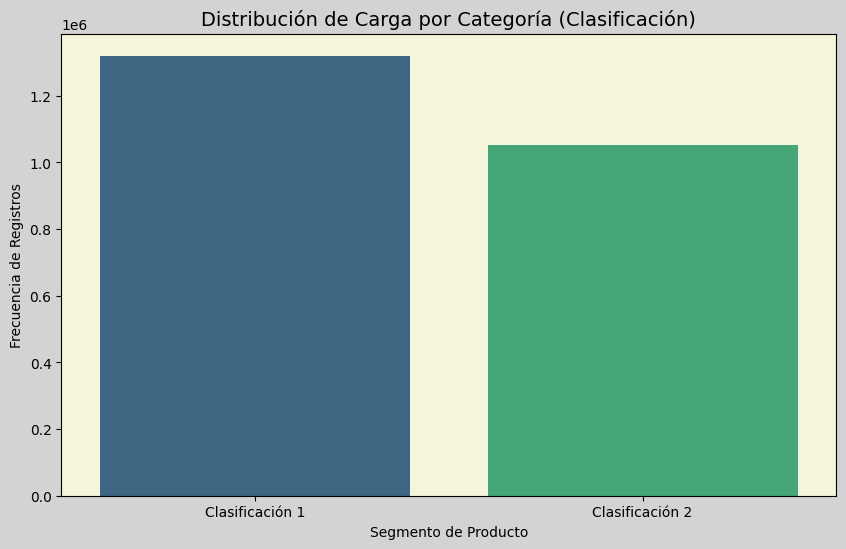

In [21]:
# Consolidación de los 10 artículos con mayor volumen de compra
top_adquisiciones = df_compras.groupby(['Marca_ID', 'Descripcion', 'Precio_Compra'])['Cantidad'].sum().nlargest(10).reset_index()

print("Ranking de los 10 Productos con Mayor Volumen de Compra:")
display(top_adquisiciones)

# Visualización de la distribución por tipo de clasificación
plt.figure(figsize=(10, 6), facecolor='lightgray')
conteo_clases = df_compras['Clasificacion'].value_counts()

sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='viridis')
plt.gca().set_facecolor('beige')

plt.title('Distribución de Carga por Categoría (Clasificación)', fontsize=14)
plt.xlabel('Segmento de Producto')
plt.ylabel('Frecuencia de Registros')
plt.xticks([0, 1], ['Clasificación 1', 'Clasificación 2'])
plt.show()

Paso 22: Eficiencia Logística (Lead Time de Entrega)
- Descripción: "Calculamos el tiempo transcurrido entre la emisión de la orden y la recepción física del producto. Analizamos la distribución de estos días de demora para identificar el promedio de respuesta de los proveedores y detectar posibles cuellos de botella."

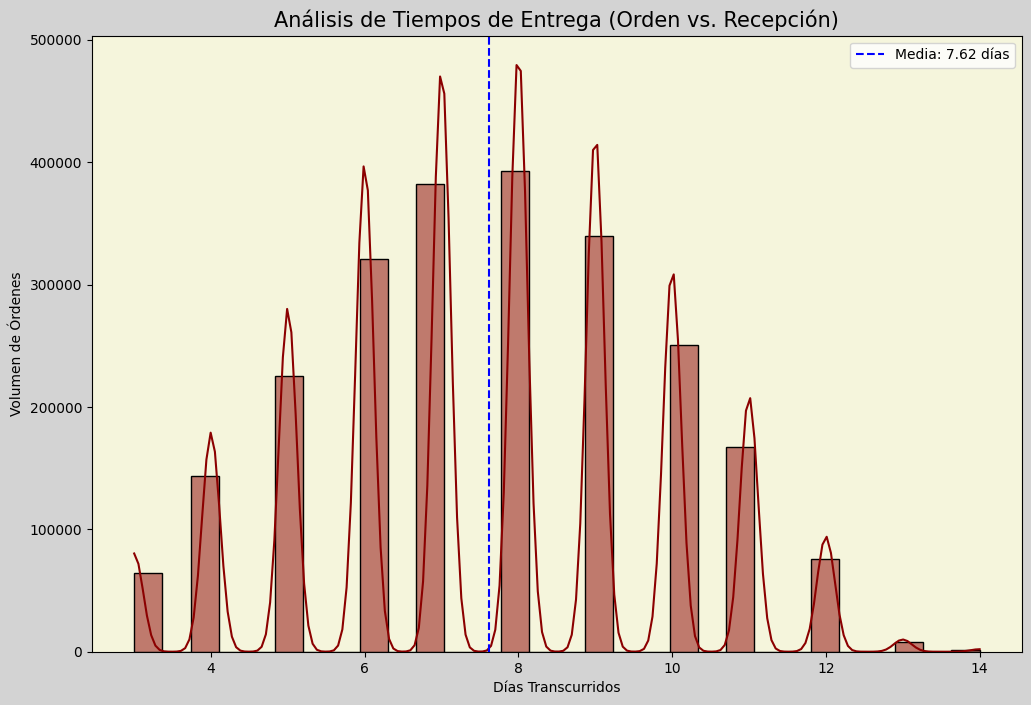

In [22]:
# Cálculo de la métrica de demora en días (Lead Time)
df_compras['Diferencia_Dias'] = (df_compras['Fecha_Recepcion'] - df_compras['Fecha_Orden_Compra']).dt.days

# Generación del histograma de tiempos de entrega
plt.figure(figsize=(12, 8), facecolor='lightgray')
sns.histplot(df_compras['Diferencia_Dias'], bins=30, kde=True, color='darkred')
plt.gca().set_facecolor('beige')

# Marcamos la tendencia central (Promedio)
promedio_demora = df_compras['Diferencia_Dias'].mean()
plt.axvline(promedio_demora, color='blue', linestyle='--', label=f'Media: {promedio_demora:.2f} días')

plt.title('Análisis de Tiempos de Entrega (Orden vs. Recepción)', fontsize=15)
plt.xlabel('Días Transcurridos')
plt.ylabel('Volumen de Órdenes')
plt.legend()
plt.show()

Paso 23: Exportación Final de Compras Saneadas
- Descripción: "Persistimos el dataset final en la carpeta de resultados procesados utilizando la nomenclatura estándar. Este archivo contiene todas las correcciones de precios, fechas normalizadas y el cálculo de demora logística."

In [23]:
# Definición de la ruta según la nueva nomenclatura solicitada
ruta_final_compras = "../data/DatosProcesados/Detalle_Compras_Limpias_Final.csv"

# Exportación definitiva a CSV
df_compras.to_csv(ruta_final_compras, index=False)

print(f"Sincronización completa: Archivo '{ruta_final_compras}' generado exitosamente.")

Sincronización completa: Archivo '../data/DatosProcesados/Detalle_Compras_Limpias_Final.csv' generado exitosamente.


Paso 24: Transformación a Modelo Dimensional (Split de Tablas)
-  Descripción: "Segmentamos el dataset de detalle de compras para separar los atributos maestros del producto de las métricas de adquisición. Este paso es crucial para normalizar la base de datos y cumplir con el diseño de esquema estrella."

In [28]:
# --- GENERACIÓN DE DIMENSIONES ---

# 1. Dim_Producto: Extraemos los atributos únicos
columnas_producto = ['Marca_ID', 'Descripcion', 'Tamaño', 'Clasificacion']
dim_producto = df_compras[columnas_producto].drop_duplicates().reset_index(drop=True)

# 2. Dim_Calendario: Generamos las llaves temporales
# CORRECCIÓN: Se utiliza 'Fecha_Orden_Compra' que es el nombre definido en el Paso 8
df_compras['Fecha_ID'] = pd.to_datetime(df_compras['Fecha_Orden_Compra']).dt.strftime('%Y%m%d').astype(int)

Paso 25: Construcción de la Tabla de Hechos (Fact_Compras_Detalle)
- Descripción: "Estructuramos la tabla de hechos de compras manteniendo únicamente las llaves foráneas (FK) y las métricas de cantidad y precio. Esto permite una relación eficiente con las dimensiones de Producto y Proveedor."

In [29]:
# Selección de columnas para la Fact Table según el diagrama
fact_compras_detalle = df_compras[[
    'Detalle_Compra_ID', # Primary Key definida en tu limpieza
    'Compra_ID',         # FK para agrupar por factura
    'Marca_ID',          # FK a Dim_Producto
    'Proveedor_ID',      # FK a Dim_Proveedor
    'Fecha_ID',          # FK a Dim_Calendario
    'Cantidad',          # Métrica
    'Precio_Compra',     # Métrica
    'Importe'            # Métrica
]].reset_index(drop=True)

Paso 26: Exportación Final a la Carpeta de Ingesta
- Descripción: "Persistimos las tablas normalizadas en la carpeta de DatosIngesta. Estos archivos están listos para ser cargados en SQL Server, asegurando que la estructura del almacén de datos (DWH) coincida con el modelo lógico diseñado."

In [30]:
# Definición de la ruta organizada
ruta_ingesta = "../data/DatosIngesta/"

# Exportación definitiva de las piezas del modelo estrella
dim_producto.to_csv(ruta_ingesta + "Dim_Producto.csv", index=False)
fact_compras_detalle.to_csv(ruta_ingesta + "Fact_Compras.csv", index=False)

print(f"Tablas generadas exitosamente en: {ruta_ingesta}")

Tablas generadas exitosamente en: ../data/DatosIngesta/
